In [66]:
import astropy.units as u
import astropy.coordinates as apycoords
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
def xyzuvw(ra, dec, distance, pmra, pmdec, radial_velocity):
    """
    Converts ICRS ra (deg), dec (deg), parallax (mas), pmra (mas/yr),
    pmdec (mas/yr), and radial velocity (km/s) to heliocentric
    Cartesian XYZ (pc) and UVW (km/s)

    Args:
        ra (array-like): Right ascension in degrees
        dec (array-like): Declination in degrees
        distance (array-like): Distance in parsecs
        pmra (array-like): Proper motion in right ascension (mas/yr)
        pmdec (array-like): Proper motion in declination (mas/yr)
        radial_velocity (array-like): Radial velocity in km/s

    Returns:
        numpy.ndarray : (n x 6) XYZUVW array
    """

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=distance * u.pc,
        pm_ra_cosdec=pmra * u.mas / u.yr,
        pm_dec=pmdec * u.mas / u.yr,
        radial_velocity=radial_velocity * u.km / u.s,
        frame="icrs",
    )

    cg = c.transform_to(apycoords.Galactic())
    cg.representation_type = "cartesian"

    xyz = cg.cartesian.xyz.value.T.reshape(-1, 3)
    uvw = np.vstack([cg.U.value, cg.V.value, cg.W.value]).T
    xyzuvw = np.concatenate([xyz, uvw], axis=1)

    return xyzuvw


def galcen_cyl(ra, dec, distance, pmra, pmdec, radial_velocity):
    """
    Converts ICRS ra (deg), dec (deg), parallax (mas), pmra (mas/yr),
    pmdec (mas/yr), and radial velocity (km/s) to Galactocentric cylindrical coordinates
    rho (kpc), phi (deg), z (pc), v_rho (km/s), v_phi (km/s), v_z (km/s)

    LEFT-HANDED

    Args:
        ra (array-like): Right ascension in degrees
        dec (array-like): Declination in degrees
        distance (array-like): Distance in parsecs
        pmra (array-like): Proper motion in right ascension (mas/yr)
        pmdec (array-like): Proper motion in declination (mas/yr)
        radial_velocity (array-like): Radial velocity in km/s

    Returns:
        numpy.ndarray: (n x 6) array of galactocentric cylindrical coordinates


    """

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=distance * u.pc,
        pm_ra_cosdec=pmra * u.mas / u.yr,
        pm_dec=pmdec * u.mas / u.yr,
        radial_velocity=radial_velocity * u.km / u.s,
        frame="icrs",
    )

    v_sun = apycoords.CartesianDifferential([11.1, 245.0, 7.25] * u.km / u.s)
    gc_frame = apycoords.Galactocentric(
        galcen_distance=8.25 * u.kpc, z_sun=20.8 * u.pc, galcen_v_sun=v_sun
    )

    gc = c.transform_to(gc_frame)
    gc.representation_type = "cylindrical"

    cyl_coord = np.vstack(
        [
            gc.rho.to(u.kpc).value,
            180 - gc.phi.degree,
            gc.z.to(u.pc).value,
            gc.d_rho.to(u.km / u.s).value,
            -(gc.d_phi * gc.rho)
            .to(u.km / u.s, equivalencies=u.dimensionless_angles())
            .value,
            gc.d_z.to(u.km / u.s).value,
        ]
    ).T

    return cyl_coord

In [54]:
hclu = pd.read_csv("/Volumes/travelpassport/litclusterdatabases/HR24/HR24_clusters.csv")
hmem = pd.read_hdf("/Volumes/travelpassport/litclusterdatabases/HR24/HR24_members.h5")


open_cond = (
    (hclu.dist16 < 500) & (hclu.CST > 5) & (hclu.Type == "o") & (hclu.RV.notna())
)
mg_cond = (hclu.dist16 < 500) & (hclu.CST > 10) & (hclu.Type == "m") & (hclu.RV.notna())
cond = open_cond | mg_cond

hclu = hclu.loc[cond].reset_index(drop=True).copy()

hmem = hmem.loc[hmem.Name.isin(hclu.Name)].reset_index(drop=True).copy()

In [99]:
df = hclu[
    [
        "Name",
        "RA_ICRS",
        "DE_ICRS",
        "GLON",
        "GLAT",
        "pmRA",
        "pmDE",
        "RV",
        "n_RV",
        "Plx",
    ]
]

df = df.rename(
    columns={
        "Name": "name",
        "RA_ICRS": "ra",
        "DE_ICRS": "dec",
        "GLON": "l",
        "GLAT": "b",
        "pmRA": "pmra",
        "pmDE": "pmdec",
        "Plx": "plx",
    }
)

In [101]:
df[["x", "y", "z", "u", "v", "w"]] = xyzuvw(
    df.ra.values,
    df.dec.values,
    1000 / df.plx.values,
    df.pmra.values,
    df.pmdec.values,
    df.RV.values,
)

df[["rho", "phi", "z", "v_rho", "v_phi", "v_z"]] = galcen_cyl(
    df.ra.values,
    df.dec.values,
    1000 / df.plx.values,
    df.pmra.values,
    df.pmdec.values,
    df.RV.values,
)

In [64]:
clu_params = pd.read_csv("../data/clu_params.csv")

(array([ 16.,  37.,  81., 119.,  28.,   4.,   1.,   1.,   0.,   1.]),
 array([-25.07460037, -23.73806043, -22.40152049, -21.06498055,
        -19.72844061, -18.39190067, -17.05536073, -15.71882079,
        -14.38228085, -13.04574091, -11.70920097]),
 <BarContainer object of 10 artists>)

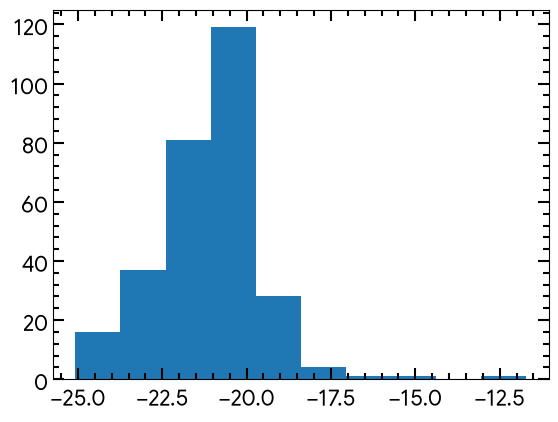

In [71]:
plt.hist(clu_params.z - df.z)

(array([  4.,  42., 175.,  50.,  15.,   1.,   0.,   0.,   0.,   1.]),
 array([16.08365017, 18.25491127, 20.42617237, 22.59743347, 24.76869457,
        26.93995567, 29.11121677, 31.28247787, 33.45373897, 35.62500007,
        37.79626117]),
 <BarContainer object of 10 artists>)

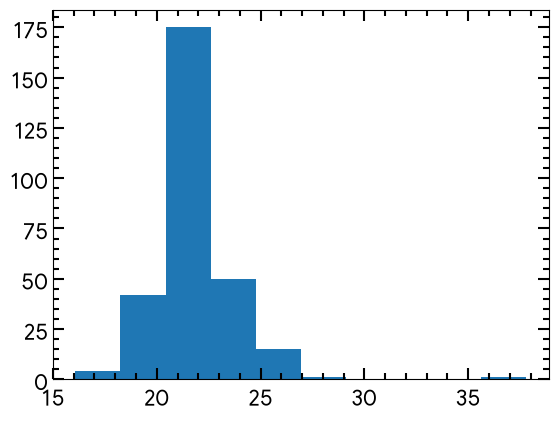

In [75]:
plt.hist(
    np.sqrt(
        (clu_params.z - df.z) ** 2
        + (clu_params.x - df.x) ** 2
        + (clu_params.y - df.y) ** 2
    )
)

(array([76., 66., 58., 44., 25.,  8.,  8.,  2.,  0.,  1.]),
 array([ 0.04531551,  2.01618062,  3.98704573,  5.95791083,  7.92877594,
         9.89964105, 11.87050615, 13.84137126, 15.81223637, 17.78310147,
        19.75396658]),
 <BarContainer object of 10 artists>)

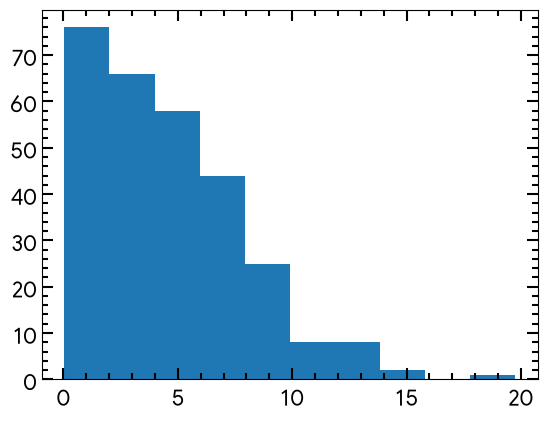

In [79]:
plt.hist(np.abs(1000 / hclu.Plx - hclu.dist50), bins=10)

<Axes: >

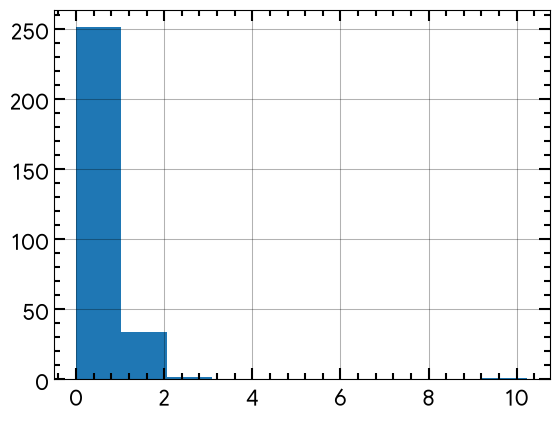

In [13]:
(hclu.dist84 - hclu.dist16).hist()

<Axes: >

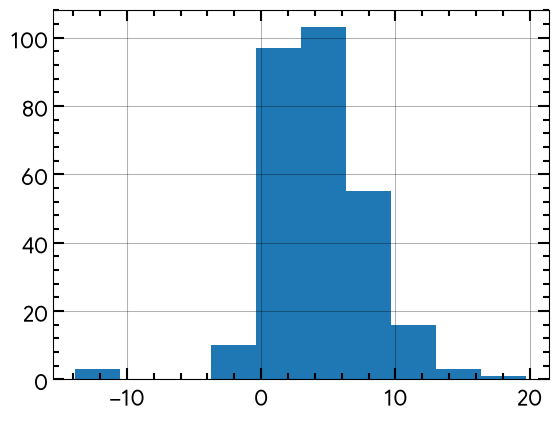

In [24]:
(1000 / hclu.Plx - hclu.dist50).hist()

(array([  7.,  28.,  56., 123.,  50.,  14.,   6.,   3.,   0.,   1.]),
 array([-10.03040747,  -7.12750374,  -4.22460001,  -1.32169628,
          1.58120745,   4.48411119,   7.38701492,  10.28991865,
         13.19282238,  16.09572612,  18.99862985]),
 <BarContainer object of 10 artists>)

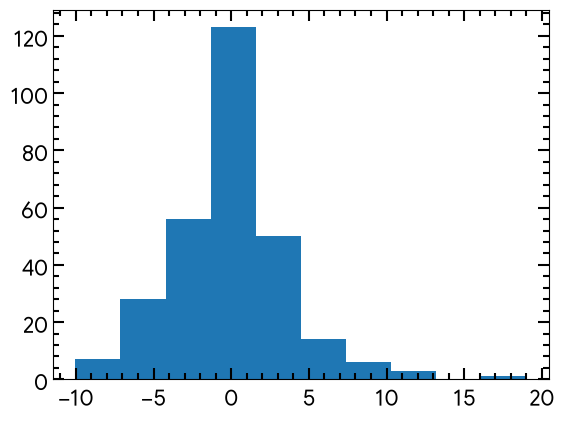

In [98]:
plt.hist(clu_params.x - df.x)

In [103]:
import duckdb

In [105]:
df = duckdb.sql("""

    SELECT source_id

    FROM read_parquet('/Volumes/travelpassport/tables/allskylitjoin/*.parquet')

""").df()

In [106]:
df

,source_id
0,4046056250307104896
1,4046057349810951424
2,4046043227953642752
3,4046043399752981504
4,4046043915160896768
...,...
119956446,4109406124504435072
119956447,4109441618124033152
119956448,4109442064800829312
119956449,4109442717676143744
